# Citi Bike Rebalancing-03

This notebook trains a Deep Q-Network on the same two-station Citi Bike rebalancing environment used in `02_sarsa_qlearning.ipynb`. The repeated setup sections make this notebook runnable on its own.
<div style="color:#b00020; background-color:#fff3f3; padding:10px; border-left:4px solid #b00020;">
<b>Note:</b> Readers who have already reviewed <code>02__sarsa_qlearning.ipynb</code> can start from the <b>DQN</b> section.

The main modeling difference is that DQN uses a feature encoder with hour, inventory, inventory difference, and **day-of-week information**, allowing the network to learn weekly demand patterns.
</div>

The notebook has five main steps:

1. Load the processed hourly train/test data from `01_data_processing.ipynb` and convert it into daily episode dictionaries.

2. Define the same two-station Citi Bike environment used in the tabular RL notebook.

3. Train the DQN agent using a pure NumPy implementation with a dueling head, Double DQN target, Huber loss, Adam optimizer, and gradient clipping.

4. Evaluate DQN on the same February 2026 test set.

5. Compare DQN with the tabular RL results and visualize final performance.

Two DQN-specific stabilizers are included:

- **Experience replay**: past transitions are stored in a fixed-size buffer and randomly sampled for gradient updates.
- **Target network**: a second copy of the Q-network produces TD targets and is updated from the online network every 100 environment steps.

The outputs of this notebook are:

- `results/final_model_comparison.csv`
- `results/final_test_daily_unmet.csv`
- `results/dqn_model/dqn_two_station_seed42.json`

In [4]:
import json
from collections import deque, Counter
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

**Load hourly data and convert to dictionary form**

In [5]:
train_data = pd.read_csv(PROCESSED_DIR / "train_hourly.csv")
test_data = pd.read_csv(PROCESSED_DIR / "test_hourly.csv")
station_info = pd.read_csv(PROCESSED_DIR / "station_info.csv")
train_data["date"] = pd.to_datetime(train_data["date"])
test_data["date"] = pd.to_datetime(test_data["date"])

def to_daily_dict(df):
    """
    Convert hourly environment data into daily episode dictionaries.

    Each key is one date.
    Each value contains 24-hour departure and arrival arrays
    for the two selected stations.
    """

    daily = {}
    for date, day_df in df.groupby("date"):
        day_df = day_df.sort_values("hour").copy()
        daily[date] = { "departures": day_df[["d_s1", "d_s2"]].to_numpy(dtype=int),"arrivals": day_df[["r_s1", "r_s2"]].to_numpy(dtype=int)}
    return daily

train_daily = to_daily_dict(train_data)
test_daily = to_daily_dict(test_data)

print("Number of train episodes:", len(train_daily))
print("Number of test episodes:", len(test_daily))

Number of train episodes: 396
Number of test episodes: 28


**Evironment Setup**

In [6]:
class CitiBikeEnv:
    """
    A two-station Citi Bike rebalancing environment.

    Environment rules:
        - One episode is one day, with 24 hourly steps.
        - At the beginning of each episode, both stations start with the
          same initial inventory.
        - The agent can move bikes between the two selected stations at the
          beginning of each hour.
        - No bikes are added from outside the system.

    State:
        (hour, b1, b2)

    Actions:
        0: do nothing
        1-20: move action bikes from station 1 to station 2
        21-40: move action - 20 bikes from station 2 to station 1

    Actual moved amount:
        moved_bikes = min(
            intended_amount,
            source_inventory,
            capacity - target_inventory
        )

    Reward:
        reward = - total unmet demand - operation_cost * move_action

    where:
        move_action = 1 if at least one bike is actually moved,
        move_action = 0 otherwise.
    """

    def __init__(self, capacity=20, init_inventory=10, operation_cost=0.1):
        self.capacity = capacity
        self.init_inventory = init_inventory
        self.operation_cost = operation_cost
        self.n_stations = 2
        self.n_hours = 24
        self.action_space = list(range(41))
        self.inventory = None
        self.hour = None
        self.departures = None
        self.arrivals = None

    def reset(self, day_data):
        """
        Reset the environment with one day's data.

        day_data should contain:
            {
                "departures": np.array of shape (24, 2),
                "arrivals": np.array of shape (24, 2)
            }

        Returns:
            initial state: (hour, b1, b2)
        """

        self.departures = day_data["departures"]
        self.arrivals = day_data["arrivals"]
        self.inventory = np.full(self.n_stations, self.init_inventory, dtype=int)
        self.hour = 0

        return self._state()

    def _state(self):
        """
        Return the current state as:(hour, b1, b2)
        """

        return (int(self.hour), int(self.inventory[0]),int(self.inventory[1]))

    def _decode_action(self, action):
        """
        Convert action number into source, target, and intended move amount.

        Returns:
            source, target, intended_amount

        Action meaning:
            0: do nothing
            1-20: station 1 -> station 2
            21-40: station 2 -> station 1
        """

        if action == 0:
            return None, None, 0

        if 1 <= action <= 20:
            source = 0
            target = 1
            intended_amount = action
        elif 21 <= action <= 40:
            source = 1
            target = 0
            intended_amount = action - 20

        return source, target, intended_amount

    def step(self, action):
        """
        Run one hourly step.

        Parameters
        ----------
        action : int
            0 = do nothing
            1-20 = move 1-20 bikes from station 1 to station 2
            21-40 = move 1-20 bikes from station 2 to station 1

        Returns
        -------
        next_state : tuple or None
            Next state after transition, or None if the episode is over.

        reward : float
            Negative unmet demand minus operation cost.

        done : bool
            Whether the daily episode is over.

        info : dict
            Extra diagnostic information for evaluation.
        """
        inventory = self.inventory.copy()

        # 1. Move bikes before serving departure demand
        source, target, intended_amount = self._decode_action(action)

        moved_bikes = 0

        if action != 0:
            moved_bikes = min(
                intended_amount,
                inventory[source],
                self.capacity - inventory[target]
            )

            inventory[source] -= moved_bikes
            inventory[target] += moved_bikes

        inventory_after_move = inventory.copy()

        # 2. Serve departures and calculate unmet demand
        dep = self.departures[self.hour]

        served = np.minimum(inventory_after_move, dep)
        unmet = np.maximum(0, dep - inventory_after_move)

        # 3. Add arrivals and update inventory
        arr = self.arrivals[self.hour]

        new_inventory = inventory_after_move - served + arr
        new_inventory = np.minimum(self.capacity, new_inventory)
        new_inventory = np.maximum(0, new_inventory)

        # 4. Reward
        total_unmet = int(unmet.sum())
        total_served = int(served.sum())
        move_action = int(moved_bikes > 0)

        reward = -total_unmet - self.operation_cost * move_action

        # 5. Enter next hour
        self.inventory = new_inventory.astype(int)
        self.hour += 1

        done = self.hour == self.n_hours
        if done:
            next_state = None
        else:
            next_state = self._state()

        info = {
            "served": total_served,
            "unmet": total_unmet,
            "moved_bikes": int(moved_bikes),
            "move_action": move_action,
            "inventory": self.inventory.copy()
        }

        return next_state, reward, done, info

## DQN
### Feature Encoder

DQN consumes a 12-dim feature vector built from the raw observation `(hour, b1, b2)` plus the current day-of-week:

- 2 dims: `sin(2π·h/24), cos(2π·h/24)` — cyclic time of day
- 7 dims: day-of-week one-hot (Mon=0..Sun=6)
- 2 dims: `b1/capacity, b2/capacity` — normalized inventories
- 1 dim: `(b1 - b2)/capacity` — inventory differential

**Feature encoder.** Produces the 16-dim feature vector for any `(obs, day_of_week)`.

In [7]:
class FeatureEncoder:
    """Encode (obs, dow) into a 12-dim feature vector for the DQN.

    Layout:
      [0:2]   sin/cos of hour-of-day (cyclic encoding so hour 0 is adjacent to hour 23)
      [2:9]   day-of-week one-hot (Mon=0..Sun=6)
      [9:11]  per-station normalized inventory (b_i / capacity)
      [11]    inventory differential (b1 - b2) / capacity
    """

    def __init__(self, capacity=20):
        self.capacity = capacity
        self.feature_dim = 12

    def __call__(self, obs, dow):
        """Return the 12-dim float feature vector for state (hour, b1, b2) on day-of-week dow."""
        hour, b1, b2 = obs
        angle = 2.0 * np.pi * float(hour) / 24.0
        time_feats = [np.sin(angle), np.cos(angle)]
        dow_one_hot = [0.0] * 7
        dow_one_hot[int(dow)] = 1.0
        b1_norm = b1 / self.capacity
        b2_norm = b2 / self.capacity
        diff = (b1 - b2) / self.capacity
        return np.array(
            time_feats + dow_one_hot + [b1_norm, b2_norm, diff],
            dtype=float,
        )

encoder = FeatureEncoder()
print(f"Feature dim: {encoder.feature_dim}")

Feature dim: 12


**Encoder unit test**: Sanity-check that the encoder produces the expected slots for a known input. Catches encoder bugs before any training is wasted.

In [10]:
def test_feature_encoder():
    """
    Sanity check for the DQN feature encoder.
    """

    enc = FeatureEncoder(capacity=20)
    obs = (8, 10, 5)
    dow = 2
    features = enc(obs, dow)

    assert features.shape == (12,)

    angle = 2.0 * np.pi * 8.0 / 24.0
    np.testing.assert_allclose(features[0], np.sin(angle))
    np.testing.assert_allclose(features[1], np.cos(angle))

    expected_dow = np.zeros(7)
    expected_dow[2] = 1.0

    np.testing.assert_array_equal(features[2:9], expected_dow)
    np.testing.assert_allclose(features[9], 10 / 20)
    np.testing.assert_allclose(features[10], 5 / 20)
    np.testing.assert_allclose(features[11], (10 - 5) / 20)

    print("Feature encoder test passed.")
    print(f"Sample features for obs=(8,10,5), dow=2: {features.round(3).tolist()}")


test_feature_encoder()

Feature encoder test passed.
Sample features for obs=(8,10,5), dow=2: [0.866, -0.5, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.25, 0.25]


### Define Replay Buffer


Pure NumPy implementation with the two stabilizers required for stable Q-learning + neural network training:

- **Experience replay buffer** stores past transitions and supplies decorrelated minibatches for each gradient update.
- **Target network** is a hard-copied version of the online network used to compute TD targets, synced every `target_update_interval` environment steps.

Architecture: 12 → 64 → 64 with dueling value/advantage heads → 41-dim Q-values. Loss: Huber. Target: Double DQN. Optimizer: Adam with global gradient-norm clip.


In [11]:
class ReplayBuffer:
    """Fixed-size circular buffer of (s, a, r, s_next, done) transitions.

    Old transitions are evicted in FIFO order once `capacity` is reached. Each gradient
    update samples a random mini-batch from the buffer (without replacement) so consecutive
    transitions in time are decorrelated within each batch.
    """

    def __init__(self, capacity=20000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        """Append a transition. Tensors are copied to make the buffer immune to mutation upstream."""
        self.buf.append((s.copy(), int(a), float(r), s_next.copy(), float(done)))

    def sample(self, batch_size, rng):
        """Draw a random batch of `batch_size` transitions without replacement.

        Returns (states, actions, rewards, next_states, dones) as numpy arrays stacked along
        the batch axis.
        """
        idx = rng.choice(len(self.buf), size=min(batch_size, len(self.buf)), replace=False)
        batch = [self.buf[int(i)] for i in idx]
        s = np.stack([b[0] for b in batch])
        a = np.array([b[1] for b in batch], dtype=int)
        r = np.array([b[2] for b in batch], dtype=float)
        sn = np.stack([b[3] for b in batch])
        d = np.array([b[4] for b in batch], dtype=float)
        return s, a, r, sn, d

    def __len__(self):
        return len(self.buf)


### Define DQN Network and Optimizer
**Network and Adam optimizer.** Two hidden layers (64 each, ReLU), dueling head: a single value scalar `V(s)` and an advantage vector `A(s, ·)` combine as `Q(s, a) = V(s) + A(s, a) - mean_a A(s, ·)`.

In [12]:
def init_network(input_dim, hidden_dim, output_dim, rng):
    """Initialize a dueling DQN's parameters with He scaling.

    Returns a dict with keys W1, b1, W2, b2 (shared trunk), Wv, bv (value head, scalar),
    Wa, ba (advantage head, output_dim). The dueling Q-value is V(s) + A(s,a) - mean_a A(s,a).
    """
    s1 = np.sqrt(2.0 / max(input_dim, 1))
    s2 = np.sqrt(2.0 / max(hidden_dim, 1))
    return {
        "W1": rng.normal(0.0, s1, (input_dim, hidden_dim)),
        "b1": np.zeros(hidden_dim),
        "W2": rng.normal(0.0, s2, (hidden_dim, hidden_dim)),
        "b2": np.zeros(hidden_dim),
        "Wv": rng.normal(0.0, s2, (hidden_dim, 1)),
        "bv": np.zeros(1),
        "Wa": rng.normal(0.0, s2, (hidden_dim, output_dim)),
        "ba": np.zeros(output_dim),
    }

def forward(net, x):
    """Forward pass producing dueling Q-values.

    Input shape: (batch, input_dim). Output Q shape: (batch, output_dim).
    Returns (q, cache) where cache holds the intermediate activations needed for backprop.
    """
    z1 = x @ net["W1"] + net["b1"]; a1 = np.maximum(z1, 0.0)
    z2 = a1 @ net["W2"] + net["b2"]; a2 = np.maximum(z2, 0.0)
    val = a2 @ net["Wv"] + net["bv"]
    adv = a2 @ net["Wa"] + net["ba"]
    q = val + adv - adv.mean(axis=1, keepdims=True)
    cache = {"x": x, "z1": z1, "a1": a1, "z2": z2, "a2": a2}
    return q, cache

def backward(net, cache, dq):
    """Backprop a gradient `dq` of shape (batch, output_dim) through the dueling network.

    Returns a dict of gradients with the same keys as `net`.
    """
    a1, a2 = cache["a1"], cache["a2"]
    z1, z2 = cache["z1"], cache["z2"]
    x = cache["x"]
    d_val = dq.sum(axis=1, keepdims=True)
    d_adv = dq - dq.mean(axis=1, keepdims=True)
    grads = {
        "Wv": a2.T @ d_val, "bv": d_val.sum(axis=0),
        "Wa": a2.T @ d_adv, "ba": d_adv.sum(axis=0),
    }
    da2 = d_val @ net["Wv"].T + d_adv @ net["Wa"].T
    dz2 = da2 * (z2 > 0.0); grads["W2"] = a1.T @ dz2; grads["b2"] = dz2.sum(axis=0)
    da1 = dz2 @ net["W2"].T
    dz1 = da1 * (z1 > 0.0); grads["W1"] = x.T @ dz1; grads["b1"] = dz1.sum(axis=0)
    return grads

def init_adam(net):
    """Initialize Adam optimizer state (first/second moment estimates and step counter) for `net`."""
    return {"m": {k: np.zeros_like(v) for k, v in net.items()},
            "v": {k: np.zeros_like(v) for k, v in net.items()},
            "t": 0}

def adam_step(net, grads, opt, lr=5e-4, gradient_clip=5.0,
              beta1=0.9, beta2=0.999, eps=1e-8):
    """In-place Adam update with global gradient-norm clipping.

    Computes the global L2 norm across all parameter gradients and rescales them so the
    norm does not exceed `gradient_clip`, then applies Adam's bias-corrected moment update.
    """
    opt["t"] += 1
    t = opt["t"]
    norm = np.sqrt(sum(float(np.sum(g * g)) for g in grads.values()))
    scale = 1.0 if (norm <= gradient_clip or norm == 0.0) else gradient_clip / norm
    for k, g in grads.items():
        g = g * scale
        opt["m"][k] = beta1 * opt["m"][k] + (1 - beta1) * g
        opt["v"][k] = beta2 * opt["v"][k] + (1 - beta2) * (g * g)
        m_hat = opt["m"][k] / (1 - beta1 ** t)
        v_hat = opt["v"][k] / (1 - beta2 ** t)
        net[k] -= lr * m_hat / (np.sqrt(v_hat) + eps)


### Define the DQN Agent
Owns the encoder, online network, target network, replay buffer, and Adam state. `get_action` is epsilon-greedy on the **online** network. `greedy_action` is pure argmax. `train_step` samples a minibatch from the buffer and applies a Double-DQN Huber-loss update.

In [13]:
class DQNAgent:
    """DQN agent with experience replay and a hard-synced target network.

    `online` net is trained on each step. `target` net produces the bootstrap target
    `r + gamma * max_a Q_target(s', a)` and is hard-copied from `online` every
    `target_update_interval` env steps (managed by the training loop, not this class).
    Action selection during training is epsilon-greedy on `online`; evaluation uses argmax.
    """

    def __init__(self, encoder, n_actions=41, hidden_dim=64,
                 replay_capacity=20000, batch_size=64, replay_warmup=256,
                 gamma=0.95, learning_rate=5e-4, gradient_clip=5.0,
                 initial_epsilon=1.0, epsilon_decay=1.0/100000, final_epsilon=0.05,
                 seed=SEED):
        self.encoder = encoder
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.replay_warmup = replay_warmup
        self.lr = learning_rate
        self.gradient_clip = gradient_clip
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.rng = np.random.default_rng(seed)
        self.online = init_network(encoder.feature_dim, hidden_dim, n_actions, self.rng)
        self.target = {k: v.copy() for k, v in self.online.items()}
        self.opt = init_adam(self.online)
        self.buffer = ReplayBuffer(replay_capacity)
        self._zero_state = np.zeros(encoder.feature_dim, dtype=float)

    def get_action(self, obs, dow):
        """Epsilon-greedy action selection on the online network. Used during training."""
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))
        s = self.encoder(obs, dow)[None, :]
        q, _ = forward(self.online, s)
        return int(np.argmax(q[0]))

    def greedy_action(self, obs, dow):
        """Pure argmax on the online network. Used at evaluation time and for the policy heatmap."""
        s = self.encoder(obs, dow)[None, :]
        q, _ = forward(self.online, s)
        return int(np.argmax(q[0]))

    def push_transition(self, obs, dow, action, reward, next_obs, next_dow, done):
        """Encode (obs, next_obs) and store the transition in the replay buffer.

        On terminal transitions next_obs is None; we substitute a zero feature vector for
        the next-state encoding (its Q-value is masked out by the (1 - done) factor in the
        target computation).
        """
        s = self.encoder(obs, dow)
        sn = self._zero_state if next_obs is None else self.encoder(next_obs, next_dow)
        self.buffer.push(s, action, reward, sn, done)

    def train_step(self):
        """One Double-DQN gradient update with Huber loss on a minibatch from the replay buffer.

        Returns the batch loss (or None if the buffer is below the warmup threshold).
        Action for the bootstrap target is selected by the online net but valued by the target
        net (Double DQN), reducing maximization bias.
        """
        if len(self.buffer) < self.replay_warmup:
            return None
        s, a, r, sn, d = self.buffer.sample(self.batch_size, self.rng)
        q_online_next, _ = forward(self.online, sn)
        q_target_next, _ = forward(self.target, sn)
        next_actions = np.argmax(q_online_next, axis=1)
        next_values = q_target_next[np.arange(len(next_actions)), next_actions]
        targets = r + self.gamma * (1.0 - d) * next_values
        q_online, cache = forward(self.online, s)
        predicted = q_online[np.arange(len(a)), a]
        td_error = predicted - targets
        abs_err = np.abs(td_error)
        deriv = np.where(abs_err > 1.0, np.sign(td_error), td_error)
        dq = np.zeros_like(q_online)
        dq[np.arange(len(a)), a] = deriv / len(a)
        grads = backward(self.online, cache, dq)
        adam_step(self.online, grads, self.opt, lr=self.lr, gradient_clip=self.gradient_clip)
        quad = np.minimum(abs_err, 1.0)
        lin = abs_err - quad
        loss = float(np.mean(0.5 * quad * quad + lin))
        return loss

    def sync_target(self):
        """Hard-copy the online network's weights into the target network."""
        self.target = {k: v.copy() for k, v in self.online.items()}

    def decay_epsilon(self):
        """Linearly decay epsilon by `epsilon_decay`, floored at `final_epsilon`."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)


### Train the DQN Agent

Each episode samples a random training day, the agent acts via epsilon-greedy on the **online** network, every transition is pushed to the replay buffer, and after `replay_warmup` transitions the agent does one gradient update per environment step. The target network is hard-synced every `target_update_interval = 100` env steps.

In [14]:
def train_dqn(train_daily, agent, n_episodes, target_update_interval=100, seed=SEED):
    """Train the DQN agent for n_episodes with experience replay and target-network sync.

    Each episode samples a random training day, runs the env to completion, pushes every
    transition to the replay buffer, and runs one gradient update per env step (after the
    buffer reaches `replay_warmup`). The target network is hard-synced every
    `target_update_interval` env steps. Epsilon decays once per episode.

    Returns (episode_rewards, episode_unmet, losses, epsilons): three lists indexed by
    episode, plus `losses` indexed by gradient update.
    """
    np.random.seed(seed)
    env = CitiBikeEnv()
    train_days = list(train_daily.keys())

    episode_rewards = []
    episode_unmet = []
    losses = []
    epsilons = []
    total_steps = 0

    for episode in range(n_episodes):
        day = np.random.choice(train_days)
        dow = pd.Timestamp(day).weekday()
        obs = env.reset(train_daily[day])

        terminated = False
        total_reward = 0
        total_unmet = 0

        while not terminated:
            action = agent.get_action(obs, dow)
            next_obs, reward, terminated, info = env.step(action)
            agent.push_transition(obs, dow, action, reward, next_obs, dow, terminated)
            loss = agent.train_step()
            if loss is not None:
                losses.append(loss)
            total_steps += 1
            if total_steps % target_update_interval == 0:
                agent.sync_target()
            total_reward += reward
            total_unmet += info["unmet"]
            obs = next_obs

        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        episode_unmet.append(total_unmet)
        epsilons.append(agent.epsilon)

        if (episode + 1) % 10000 == 0:
            recent = np.mean(episode_rewards[-1000:])
            recent_loss = np.mean(losses[-2000:]) if losses else float("nan")
            print(f"  episode {episode+1:>6} | reward(last 1k)={recent:7.2f} | "
                  f"loss(last 2k)={recent_loss:8.4f} | eps={agent.epsilon:.3f} | buffer={len(agent.buffer)}")
    return episode_rewards, episode_unmet, losses, epsilons


Build the agent and run training. **Approximate runtime: ~12 minutes for 100k episodes.**

In [15]:
dqn_agent = DQNAgent(
    encoder=encoder,
    n_actions=41,
    hidden_dim=64,
    replay_capacity=20000,
    batch_size=64,
    replay_warmup=256,
    gamma=0.95,
    learning_rate=5e-4,
    gradient_clip=5.0,
    initial_epsilon=1.0,
    epsilon_decay=1.0/100000,
    final_epsilon=0.05,
    seed=SEED,
)

print("Training DQN ...")
dqn_episode_rewards, dqn_episode_unmet, dqn_losses, dqn_epsilons = train_dqn(
    train_daily=train_daily,
    agent=dqn_agent,
    n_episodes=100000,
    target_update_interval=100,
    seed=SEED,
)
print("Done.")


Training DQN ...
  episode  10000 | reward(last 1k)= -42.01 | loss(last 2k)=  0.9511 | eps=0.900 | buffer=20000
  episode  20000 | reward(last 1k)= -40.73 | loss(last 2k)=  0.9031 | eps=0.800 | buffer=20000
  episode  30000 | reward(last 1k)= -36.94 | loss(last 2k)=  0.9286 | eps=0.700 | buffer=20000
  episode  40000 | reward(last 1k)= -36.02 | loss(last 2k)=  0.8743 | eps=0.600 | buffer=20000
  episode  50000 | reward(last 1k)= -35.33 | loss(last 2k)=  0.9438 | eps=0.500 | buffer=20000
  episode  60000 | reward(last 1k)= -33.52 | loss(last 2k)=  0.8449 | eps=0.400 | buffer=20000
  episode  70000 | reward(last 1k)= -32.50 | loss(last 2k)=  0.9019 | eps=0.300 | buffer=20000
  episode  80000 | reward(last 1k)= -31.73 | loss(last 2k)=  0.8690 | eps=0.200 | buffer=20000
  episode  90000 | reward(last 1k)= -30.15 | loss(last 2k)=  0.8843 | eps=0.100 | buffer=20000
  episode 100000 | reward(last 1k)= -27.61 | loss(last 2k)=  0.9071 | eps=0.050 | buffer=20000
Done.


### Visualize DQN Training Performance

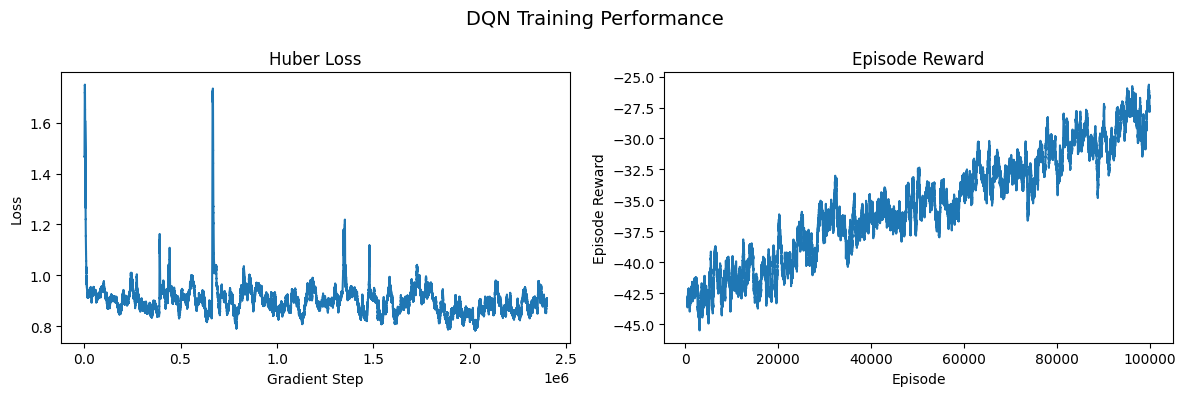

In [16]:
dqn_reward_ma = pd.Series(dqn_episode_rewards).rolling(500).mean()
dqn_loss_ma = pd.Series(dqn_losses).rolling(2000).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("DQN Training Performance", fontsize=14)

axes[0].plot(dqn_loss_ma)
axes[0].set_title("Huber Loss")
axes[0].set_xlabel("Gradient Step")
axes[0].set_ylabel("Loss")

axes[1].plot(dqn_reward_ma)
axes[1].set_title("Episode Reward")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Episode Reward")

plt.tight_layout()
plt.show()

## Evaluation Results

In [17]:
def evaluate_dqn(test_daily, agent, seed=SEED):
    """Roll out the DQN's greedy policy on every test day. Returns (summary_dict, per_day_dataframe).

    Day-of-week is resolved from each test date and passed alongside the env observation
    into the DQN agent's `greedy_action(obs, dow)` (which is why this is separate from the
    notebook's generic `evaluate_agent` used for the non-DQN baselines).
    """
    np.random.seed(seed)
    env = CitiBikeEnv()
    results = []
    for date, day_data in test_daily.items():
        dow = pd.Timestamp(date).weekday()
        obs = env.reset(day_data)
        done = False
        total_reward = total_unmet = total_served = total_moved = total_move_acts = 0
        while not done:
            action = agent.greedy_action(obs, dow)
            obs, reward, done, info = env.step(action)
            total_reward += reward
            total_unmet += info["unmet"]
            total_served += info["served"]
            total_moved += info["moved_bikes"]
            total_move_acts += info["move_action"]
        results.append({
            "date": date,
            "total_reward": total_reward,
            "total_unmet": total_unmet,
            "total_served": total_served,
            "total_moved_bikes": total_moved,
            "total_move_actions": total_move_acts,
        })
    df = pd.DataFrame(results)
    summary = {
        "avg_daily_reward": df["total_reward"].mean(),
        "avg_daily_unmet": df["total_unmet"].mean(),
        "avg_daily_served": df["total_served"].mean(),
        "avg_daily_moved_bikes": df["total_moved_bikes"].mean(),
        "avg_daily_move_actions": df["total_move_actions"].mean(),
    }
    return summary, df

dqn_summary, dqn_test_results = evaluate_dqn(test_daily, dqn_agent)
dqn_summary

{'avg_daily_reward': -4.828571428571428,
 'avg_daily_unmet': 4.0,
 'avg_daily_served': 47.92857142857143,
 'avg_daily_moved_bikes': 47.142857142857146,
 'avg_daily_move_actions': 8.285714285714286}

### Result Summary

In [29]:
tabular_summary_df = pd.read_csv(RESULTS_DIR / "tabular_summary.csv")
dqn_summary_df = pd.DataFrame([{"model": "DQN", **dqn_summary}])
final_model_comparison = pd.concat([tabular_summary_df, dqn_summary_df],ignore_index=True)
final_model_comparison

,model,avg_daily_reward,avg_daily_unmet,avg_daily_served,avg_daily_moved_bikes,avg_daily_move_actions
0,Do Nothing,-7.428571,7.428571,44.500000,0.000000,0.000000
1,Threshold Baseline,-6.810714,6.500000,45.428571,14.892857,3.107143
2,SARSA,-7.253571,5.678571,46.250000,83.857143,15.750000
3,Q-learning,-6.003571,4.642857,47.285714,77.250000,13.607143
4,DQN,-4.828571,4.000000,47.928571,47.142857,8.285714


In [30]:
final_model_comparison.to_csv(RESULTS_DIR / "final_model_comparison.csv",index=False)

### Visualize Daily Unmet Demand on the Test Set

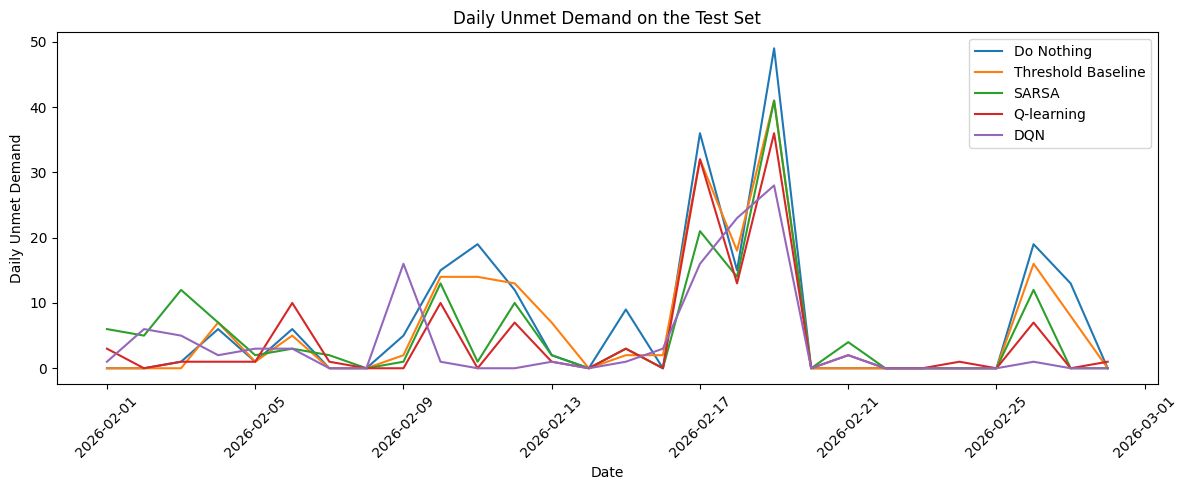

In [31]:
tabular_unmet_df = pd.read_csv(RESULTS_DIR / "tabular_test_daily_unmet.csv")
tabular_unmet_df["date"] = pd.to_datetime(tabular_unmet_df["date"])
dqn_unmet_df = dqn_test_results[["date", "total_unmet"]].copy()
dqn_unmet_df["date"] = pd.to_datetime(dqn_unmet_df["date"])
dqn_unmet_df = dqn_unmet_df.rename(columns={"total_unmet": "DQN"})
test_unmet_df = tabular_unmet_df.merge(dqn_unmet_df, on="date", how="left")

plt.figure(figsize=(12, 5))
for col in ["Do Nothing", "Threshold Baseline", "SARSA", "Q-learning", "DQN"]:
    plt.plot(test_unmet_df["date"], test_unmet_df[col], label=col)

plt.title("Daily Unmet Demand on the Test Set")
plt.xlabel("Date")
plt.ylabel("Daily Unmet Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
test_unmet_df.to_csv(RESULTS_DIR / "final_test_daily_unmet.csv", index=False)

### Visualize DQN Action Distribution
Which actions did the trained DQN actually use?

DQN test policy: total steps 672
  no_op: 258 (38.4%) | s1->s2: 173 (25.7%) | s2->s1: 241 (35.9%)
  unique actions used: 37/41


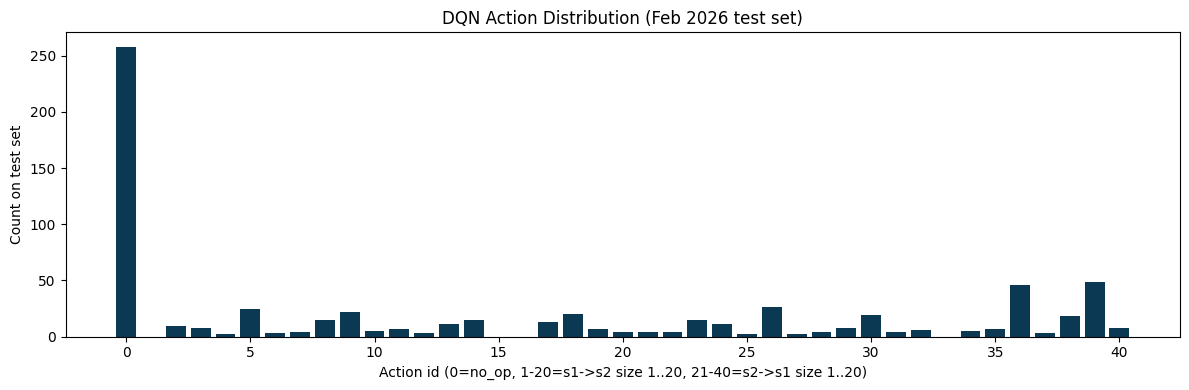

In [33]:
def collect_actions(test_daily, agent):
    """Return a flat list of every action the agent's greedy policy chose across all test episodes.

    Used to diagnose action-distribution flatness: if the agent uses all 41 actions roughly
    equally, the move-size dimension is probably not carrying real policy signal.
    """
    env = CitiBikeEnv()
    actions = []
    for date, day_data in test_daily.items():
        dow = pd.Timestamp(date).weekday()
        obs = env.reset(day_data)
        done = False
        while not done:
            a = agent.greedy_action(obs, dow)
            actions.append(a)
            obs, _, done, _ = env.step(a)
    return actions

dqn_actions = collect_actions(test_daily, dqn_agent)
counts = Counter(dqn_actions)
no_op = counts.get(0, 0)
s1_to_s2 = sum(c for a, c in counts.items() if 1 <= a <= 20)
s2_to_s1 = sum(c for a, c in counts.items() if 21 <= a <= 40)
n = len(dqn_actions)
print(f"DQN test policy: total steps {n}")
print(f"  no_op: {no_op} ({no_op/n*100:.1f}%) | s1->s2: {s1_to_s2} ({s1_to_s2/n*100:.1f}%) | s2->s1: {s2_to_s1} ({s2_to_s1/n*100:.1f}%)")
print(f"  unique actions used: {len(counts)}/41")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(41), [counts.get(a, 0) for a in range(41)], color="#0b3954")
ax.set_xlabel("Action id (0=no_op, 1-20=s1->s2 size 1..20, 21-40=s2->s1 size 1..20)")
ax.set_ylabel("Count on test set")
ax.set_title("DQN Action Distribution (Feb 2026 test set)")
plt.tight_layout()
plt.show()

### Visualize DQN Learned Policy
For each `(hour, day-of-week)` we sweep the full `(b1, b2)` inventory grid through the trained policy and record the signed move size: positive = move bikes from s1 (JC115) to s2 (JC022); negative = move from s2 to s1; zero = no-op.

If the agent had only learned "balance the inventories," every panel would look the same. Instead, panels at different `(hour, day-of-week)` combinations should differ qualitatively — Monday at hour 18 (JC115's evening commuter outflow) should call for moving bikes **toward** JC115 in advance, while Monday at hour 8 (JC115's morning commuter inflow from PATH) should call for moving bikes **away from** JC115 to make room. That direction reversal at the same station is direct evidence the network learned time-of-day context, not just an inventory rule.

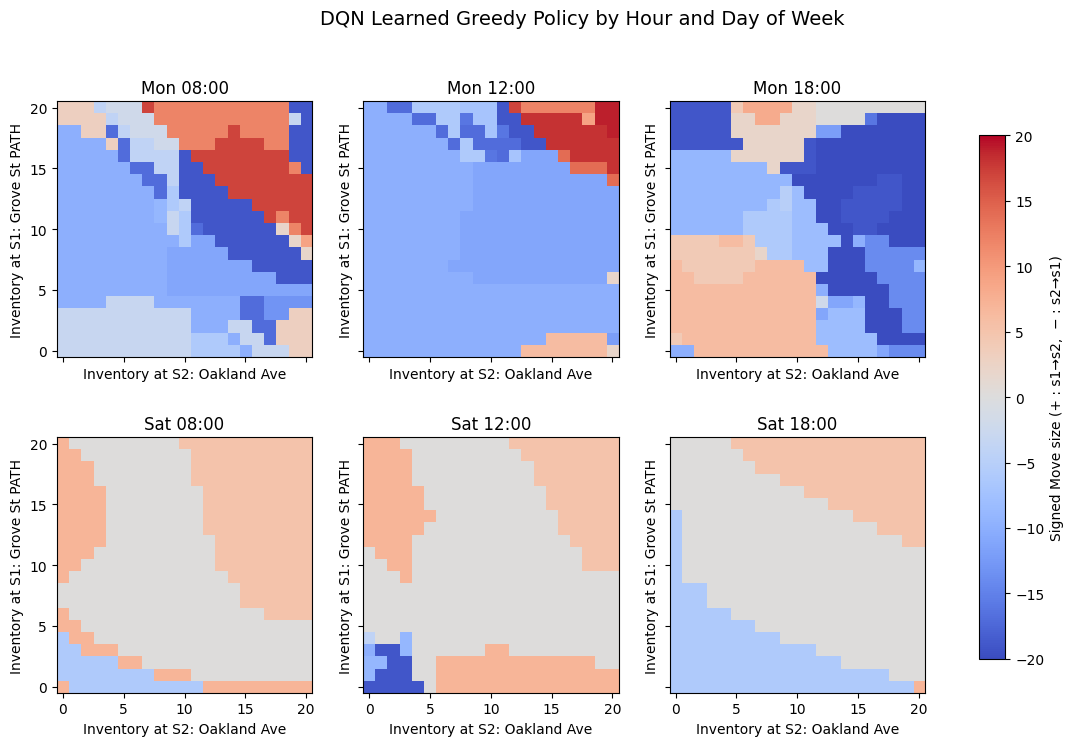

Mon 08:00    | Grove → Oakland: 108 ( 24.5%) | Oakland → Grove: 333 ( 75.5%) | No-op:   0 (  0.0%)
Mon 12:00    | Grove → Oakland:  54 ( 12.2%) | Oakland → Grove: 387 ( 87.8%) | No-op:   0 (  0.0%)
Mon 18:00    | Grove → Oakland: 142 ( 32.2%) | Oakland → Grove: 286 ( 64.9%) | No-op:  13 (  2.9%)
Sat 08:00    | Grove → Oakland: 182 ( 41.3%) | Oakland → Grove:  27 (  6.1%) | No-op: 232 ( 52.6%)
Sat 12:00    | Grove → Oakland: 154 ( 34.9%) | Oakland → Grove:  19 (  4.3%) | No-op: 268 ( 60.8%)
Sat 18:00    | Grove → Oakland:  88 ( 20.0%) | Oakland → Grove:  97 ( 22.0%) | No-op: 256 ( 58.0%)


In [34]:
def dqn_policy_grid(agent, hour, dow, capacity=20):
    """
    Return a grid of signed move sizes from the trained DQN policy.

    Positive values mean moving bikes from Grove St PATH to Oakland Ave.
    Negative values mean moving bikes from Oakland Ave to Grove St PATH.
    """

    grid = np.zeros((capacity + 1, capacity + 1), dtype=int)

    for b1 in range(capacity + 1):
        for b2 in range(capacity + 1):
            obs = (hour, b1, b2)
            action = agent.greedy_action(obs, dow)

            if action == 0:
                grid[b1, b2] = 0
            elif 1 <= action <= 20:
                grid[b1, b2] = action
            else:
                grid[b1, b2] = -(action - 20)

    return grid


panels = [
    ("Mon 08:00", 8, 0),
    ("Mon 12:00", 12, 0),
    ("Mon 18:00", 18, 0),
    ("Sat 08:00", 8, 5),
    ("Sat 12:00", 12, 5),
    ("Sat 18:00", 18, 5),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle("DQN Learned Greedy Policy by Hour and Day of Week",fontsize=14)
im = None
for ax, (title, hour, dow) in zip(axes.flat, panels):
    grid = dqn_policy_grid(dqn_agent, hour, dow)
    im = ax.imshow(grid, origin="lower", cmap="coolwarm", vmin=-20, vmax=20, aspect="equal")
    ax.set_title(title)
    ax.set_xlabel("Inventory at S2: Oakland Ave")
    ax.set_ylabel("Inventory at S1: Grove St PATH")
    ax.set_xticks(range(0, 21, 5))
    ax.set_yticks(range(0, 21, 5))
fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=0.85,
    label="Signed Move size (+ : s1\u2192s2,  \u2212 : s2\u2192s1)")
plt.show()

# Quick numeric summary of policy direction by panel (sanity check the heatmaps).
for title, hour, dow in panels:
    grid = dqn_policy_grid(dqn_agent, hour, dow)
    n = grid.size
    s1_to_s2 = int((grid > 0).sum())
    s2_to_s1 = int((grid < 0).sum())
    no_op = int((grid == 0).sum())
    print(
        f"{title:<12} | "
        f"Grove → Oakland: {s1_to_s2:>3} ({s1_to_s2 / n * 100:5.1f}%) | "
        f"Oakland → Grove: {s2_to_s1:>3} ({s2_to_s1 / n * 100:5.1f}%) | "
        f"No-op: {no_op:>3} ({no_op / n * 100:5.1f}%)"
    )

---
## Save Trained DQN Model
Persist the network weights, demand-profile, scale, hyperparameters, and metadata to JSON so the policy can be reloaded later without retraining.

In [35]:
MODEL_DIR = RESULTS_DIR / "dqn_model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def save_dqn_model(path, agent, training_config, training_metrics):
    """Serialize the trained DQN to JSON.

    Writes the online network weights, the station mapping, all training hyperparameters,
    and a compact end-of-training metrics summary. The serialized format is human-readable
    JSON so the model can be diffed in code review and reloaded without retraining.
    """
    payload = {
        "saved_at_utc": datetime.utcnow().isoformat(),
        "hyperparameters": training_config,
        "feature_dim": agent.encoder.feature_dim,
        "network": {
            k: v.tolist()
            for k, v in agent.online.items()
        },
        "training_metrics_summary": {
            "final_avg_reward_last_1000": float(np.mean(training_metrics["rewards"][-1000:])),
            "final_avg_unmet_last_1000": float(np.mean(training_metrics["unmet"][-1000:])),
            "final_epsilon": float(training_metrics["epsilons"][-1]),
            "total_episodes": len(training_metrics["rewards"]),
            "total_gradient_updates": len(training_metrics["losses"])
        }
    }

    Path(path).write_text(
        json.dumps(payload, indent=2),
        encoding="utf-8"
    )

    return path


training_config = {
    "n_episodes": 100000,
    "gamma": 0.95,
    "learning_rate": 5e-4,
    "batch_size": 64,
    "replay_capacity": 20000,
    "replay_warmup": 256,
    "hidden_dim": 64,
    "target_update_interval": 100,
    "gradient_clip": 5.0,
    "initial_epsilon": 1.0,
    "epsilon_decay": 1.0 / 100000,
    "final_epsilon": 0.05,
    "seed": SEED,
    "action_space_size": 41,
    "reward": "-unmet - 0.1 * move_indicator",
    "features": [
        "sin(hour)",
        "cos(hour)",
        "day_of_week_one_hot",
        "normalized_inventory_s1",
        "normalized_inventory_s2",
        "normalized_inventory_difference"
    ]
}

training_metrics = {
    "rewards": dqn_episode_rewards,
    "unmet": dqn_episode_unmet,
    "losses": dqn_losses,
    "epsilons": dqn_epsilons
}

model_path = save_dqn_model(
    path=MODEL_DIR / "dqn_two_station_seed42.json",
    agent=dqn_agent,
    training_config=training_config,
    training_metrics=training_metrics
)

print(f"Saved trained DQN model to: {model_path}")

Saved trained DQN model to: ../results/dqn_model/dqn_two_station_seed42.json
